In [32]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn as nn

In [33]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model=torchvision.models.mobilenet_v3_small(weights="IMAGENET1K_V1")
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

model.load_state_dict(torch.load("../models/best_model.pth",map_location=device))
model=model.to(device)
print("Model loaded successfully!")

Model loaded successfully!


In [34]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(root="../data", transform=val_transforms)
class_names  = full_dataset.classes   # ['fire', 'no_fire']

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

torch.manual_seed(42)   # same seed = same split as training
_, val_dataset = random_split(full_dataset, [train_size, val_size])

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Validation images: {len(val_dataset)}")
print(f"Classes: {class_names}")

Validation images: 228
Classes: ['fire', 'no_fire']


In [35]:
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

correct = (all_preds == all_labels).sum()
total   = len(all_labels)
print(f"Accuracy: {correct}/{total} = {100*correct/total:.2f}%")

Accuracy: 206/228 = 90.35%


In [36]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

        fire       0.97      0.89      0.93       157
     no_fire       0.80      0.93      0.86        71

    accuracy                           0.90       228
   macro avg       0.88      0.91      0.89       228
weighted avg       0.91      0.90      0.91       228



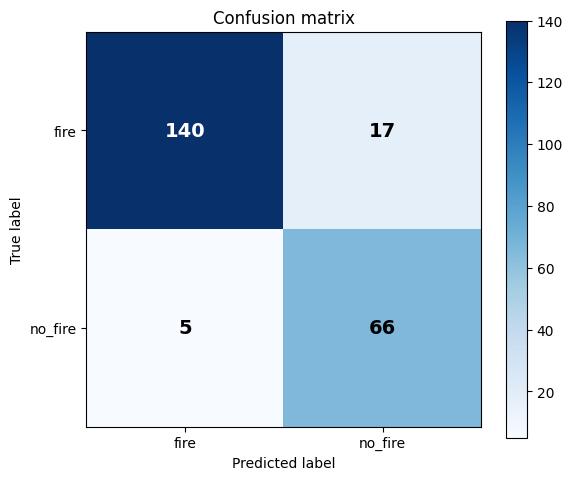


True Positives  (fire correctly detected):   140
False Negatives (fire missed):               17
False Positives (false alarm):               5
True Negatives  (no fire correctly ignored): 66


In [37]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nTrue Positives  (fire correctly detected):   {cm[0][0]}")
print(f"False Negatives (fire missed):               {cm[0][1]}")
print(f"False Positives (false alarm):               {cm[1][0]}")
print(f"True Negatives  (no fire correctly ignored): {cm[1][1]}")

Total wrong predictions: 22


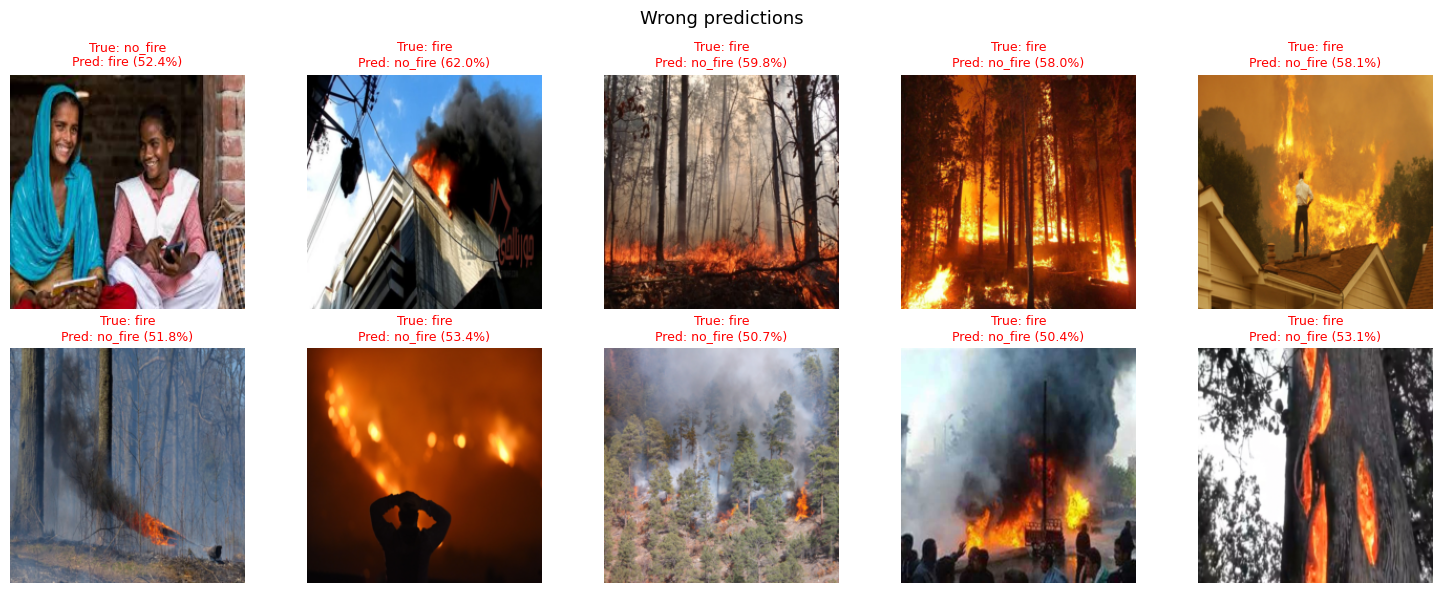

In [38]:
# find all wrong predictions
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Total wrong predictions: {len(wrong_idx)}")

if len(wrong_idx) == 0:
    print("Perfect score — no wrong predictions!")
else:
    # show up to 10 wrong ones
    show = wrong_idx[:10]
    cols = min(5, len(show))
    rows = (len(show) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(show):
        img_tensor, true_label = val_dataset[idx]

        # undo normalization for display
        mean = torch.tensor([0.485, 0.456, 0.406])
        std  = torch.tensor([0.229, 0.224, 0.225])
        img  = img_tensor * std[:, None, None] + mean[:, None, None]
        img  = img.permute(1, 2, 0).clamp(0, 1).numpy()

        pred_label = all_preds[idx]
        confidence = all_probs[idx][pred_label] * 100

        axes[i].imshow(img)
        axes[i].set_title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} ({confidence:.1f}%)",
            color="red", fontsize=9
        )
        axes[i].axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Wrong predictions", fontsize=13)
    plt.tight_layout()
    plt.show()
    

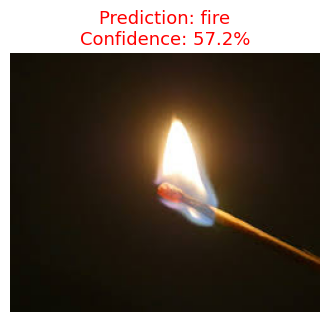

('fire', 57.1890652179718)

In [43]:
from PIL import Image

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        prob   = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()
        conf   = prob[0][pred].item() * 100

    # display
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"Prediction: {class_names[pred]}\nConfidence: {conf:.1f}%",
        color="red" if class_names[pred] == "fire" else "green",
        fontsize=13
    )
    plt.axis("off")
    plt.show()

    return class_names[pred], conf

# test it — swap path for any image you have
predict_image("../sample1.jpeg")
